## Deep Learning

## Текстовая модель: тональность отзыва

Это третья часть проекта, после EDA и табличной модели. Тут я делаю текстовую нейросеть, которая по тексту отзыва определяет его тональность - негатив, нейтрал или позитив.

Зачем это бизнесу: тональность идёт в offer engine вместе с табличным риском недовольства. Если клиент написал негатив, для него имеет смысл извинение и более щедрый оффер, если позитив - можно предлагать допродажу и лояльность. То есть текстовая модель помогает понять настроение клиента и выбрать тип оффера.

In [1]:
!pip install -q transformers datasets

In [2]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, recall_score, accuracy_score, confusion_matrix, classification_report

from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
import wandb

%matplotlib inline

In [3]:
device = torch.device("cuda")

In [4]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

seed_everything(42)

## Постановка текстовой задачи

Беру датасет reviews_text_dataset.csv, одна строка это один отзыв с текстом review_comment_message. Таргет sentiment уже посчитан на этапе EDA по review_score: оценка <= 2 это negative, == 3 это neutral, >= 4 это positive. То есть получается классификация на 3 класса.

Отзывы на португальском, это важно при выборе модели дальше.

In [5]:
df = pd.read_csv('reviews_text_dataset.csv')
df.shape

(40977, 12)

In [6]:
df = df[['review_comment_message', 'sentiment', 'review_score']].copy()
df = df.dropna(subset = ['review_comment_message', 'sentiment'])
df['review_comment_message'] = df['review_comment_message'].astype(str).str.strip()
df = df[df['review_comment_message'].str.len() > 0].reset_index(drop = True)
df.head()

,review_comment_message,sentiment,review_score
0,Recebi bem antes do prazo estipulado.,positive,5
1,Parabéns lojas lannister adorei comprar pela I...,positive,5
2,aparelho eficiente. no site a marca do aparelh...,positive,4
3,"Mas um pouco ,travando...pelo valor ta Boa.",positive,4
4,"Vendedor confiável, produto ok e entrega antes...",positive,5


In [7]:
LABELS = ['negative', 'neutral', 'positive']
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}

df['label'] = df['sentiment'].map(label2id)
df['sentiment'].value_counts()

,count
sentiment,
positive,26505
negative,10889
neutral,3556


{'positive': 0.647, 'negative': 0.266, 'neutral': 0.087}


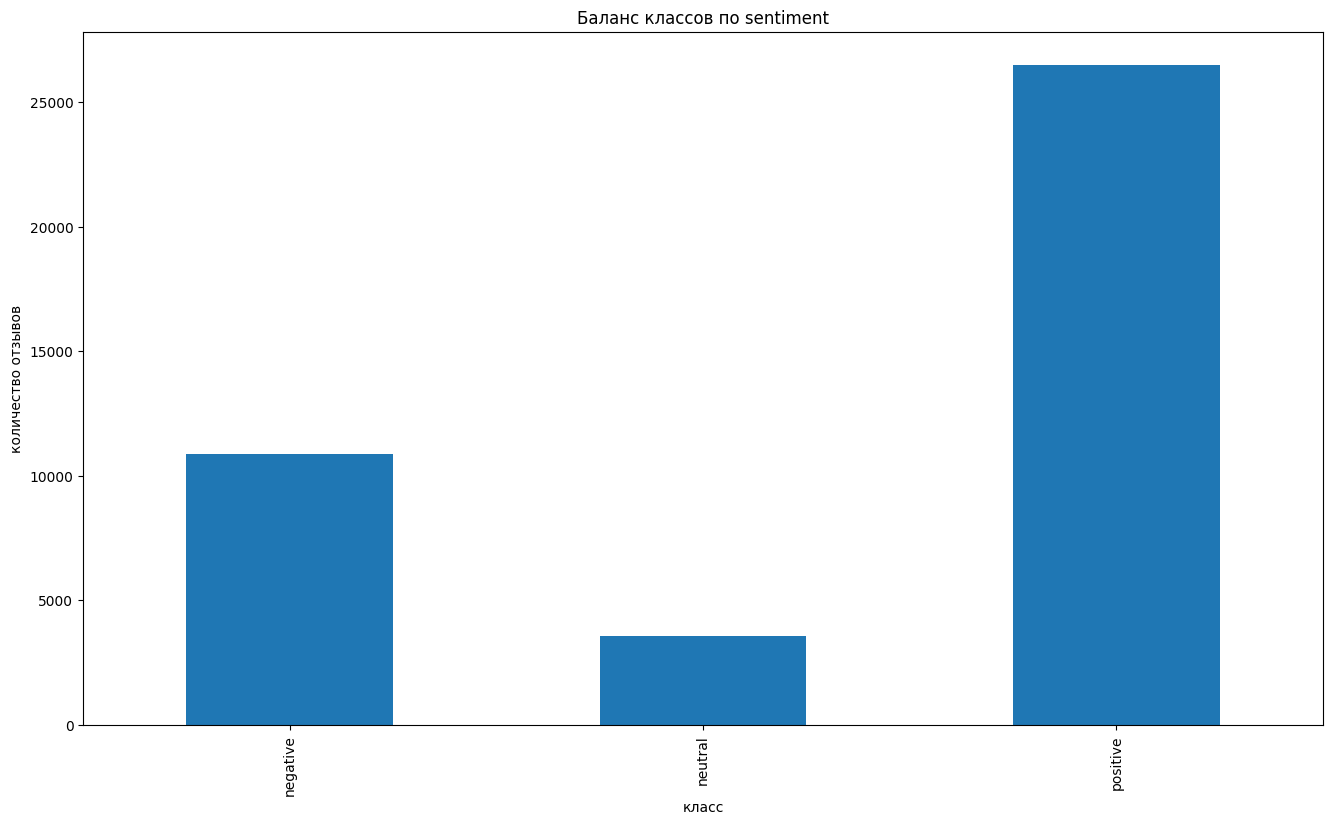

In [8]:
# баланс классов
plt.figure(figsize = (16, 9))
df['sentiment'].value_counts().reindex(LABELS).plot(kind = 'bar')
plt.title('Баланс классов по sentiment')
plt.xlabel('класс')
plt.ylabel('количество отзывов')

print(df['sentiment'].value_counts(normalize = True).round(3).to_dict())

Видим что классы несбалансированы, позитива заметно больше, а нейтрала совсем мало. Как и в табличной части, accuracy тут будет обманчивой - поэтому смотрю в первую очередь на macro F1 и отдельно на recall негатива. Для бизнеса пропустить недовольного клиента дороже, чем лишний раз ошибиться на позитиве.

## Какие модели берём

Главное ограничение - отзывы на португальском, значит модель должна нормально его понимать. Перебрал варианты и взял три штуки разного размера, чтобы было что сравнить:

- **BERTimbau** (neuralmind/bert-base-portuguese-cased) - BERT, дообученный именно на португальском. Ожидаю что будет самым точным, это наша основная модель.
- **DistilBERT multilingual** (distilbert-base-multilingual-cased) - лёгкая дистиллированная модель, учится быстрее и жрёт меньше памяти. Смотрю сколько теряем в качестве ради скорости.
- **Qwen2.5-0.5B** (Qwen/Qwen2.5-0.5B) - маленькая генеративная llm. Интересно проверить тянет ли decoder-модель классификацию, плюс её потом можно переиспользовать чтобы генерить сам текст оффера.

Совсем крошечные модели типа bert-tiny не брал - они на английском и португальский почти не понимают, для нашей задачи смысла в них нет.

## Подготовка текстов

Смотрю длины текстов, потом делю на train/val/test со стратификацией по классу. Val нужен чтобы следить за переобучением по эпохам, а финальные метрики считаю на test.

медиана 9 слов, 95 перцентиль 33


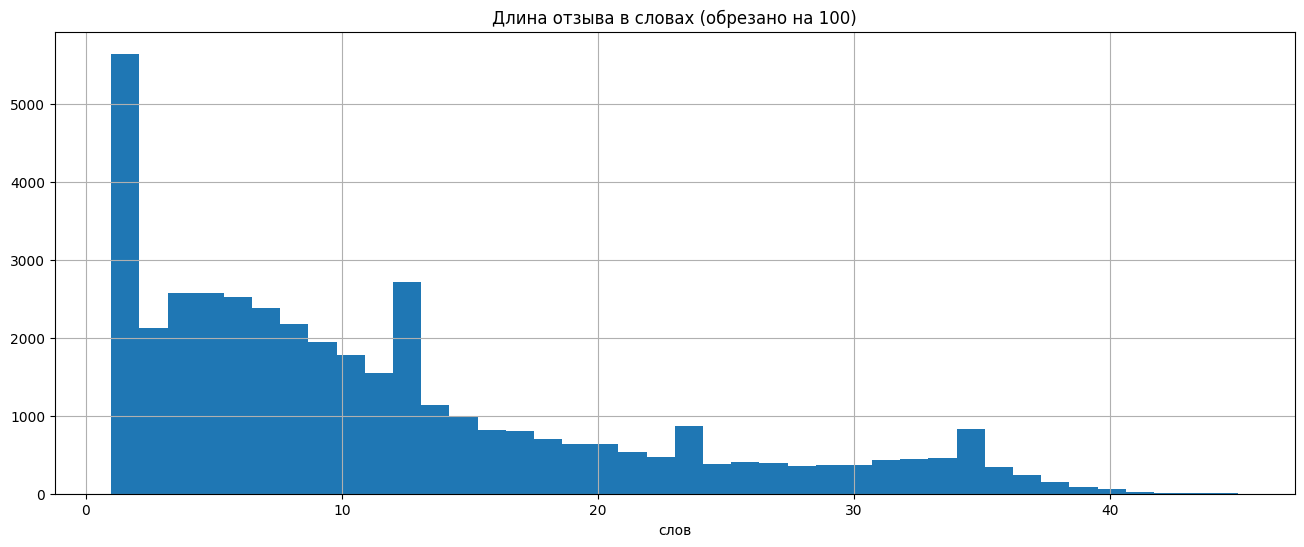

In [9]:
df['n_words'] = df['review_comment_message'].str.split().apply(len)

plt.figure(figsize = (16, 6))
df['n_words'].clip(upper = 100).hist(bins = 40)
plt.title('Длина отзыва в словах (обрезано на 100)')
plt.xlabel('слов')

print('медиана', int(df['n_words'].median()), 'слов, 95 перцентиль', int(df['n_words'].quantile(0.95)))

In [10]:
train_df, test_df = train_test_split(df, test_size = 0.2, random_state = 42, stratify = df['label'])
train_df, val_df = train_test_split(train_df, test_size = 0.1, random_state = 42, stratify = train_df['label'])

train_df = train_df.reset_index(drop = True)
val_df = val_df.reset_index(drop = True)
test_df = test_df.reset_index(drop = True)

print('train', len(train_df), 'val', len(val_df), 'test', len(test_df))

train 29484 val 3276 test 8190


In [11]:
# веса классов, чтобы редкий neutral не игнорировался
counts = train_df['label'].value_counts().reindex(range(len(LABELS))).values
class_weights = torch.tensor(counts.sum() / (len(LABELS) * counts), dtype = torch.float32)
print({LABELS[i]: round(float(class_weights[i]), 2) for i in range(len(LABELS))})

{'negative': 1.25, 'neutral': 3.84, 'positive': 0.51}


## Baseline

Перед трансформерами строю простой бэйзлайн на TF-IDF + логистической регрессии, чтобы было с чем сравнивать. Если тяжёлые модели его не бьют, смысла в них нет. Логрег беру с class_weight balanced из-за дисбаланса.

In [12]:
results = []

def evaluate(y_true, y_proba, name):
    y_pred = y_proba.argmax(1)
    res = {
        'model': name,
        'acc': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average = 'macro'),
        'recall_neg': recall_score(y_true, y_pred, labels = [label2id['negative']], average = 'macro'),
        'roc_auc': roc_auc_score(y_true, y_proba, multi_class = 'ovr', average = 'macro')
    }
    print(name, '| f1_macro', round(res['f1_macro'], 3), '| recall_neg', round(res['recall_neg'], 3),
          '| roc_auc', round(res['roc_auc'], 3))
    return res

In [13]:
tfidf = TfidfVectorizer(ngram_range = (1, 2), min_df = 3, max_features = 50000, sublinear_tf = True)
X_train = tfidf.fit_transform(train_df['review_comment_message'])
X_test = tfidf.transform(test_df['review_comment_message'])

logreg = LogisticRegression(max_iter = 1000, class_weight = 'balanced', C = 4.0)
logreg.fit(X_train, train_df['label'])

proba = logreg.predict_proba(X_test)
results.append(evaluate(test_df['label'].values, proba, 'TFIDF+LogReg'))

TFIDF+LogReg | f1_macro 0.645 | recall_neg 0.794 | roc_auc 0.869


## DL-модели для текстов

Теперь трансформеры. Инфраструктуру делаю по аналогии с табличной частью - тот же CFG, логирование в wandb, ручной цикл обучения по эпохам. Только вместо своей сети беру готовые предобученные модели из huggingface и навешиваю сверху голову классификации.

Категориальной обработки тут не надо, токенизатор сам режет текст на сабворды. Для каждой модели использую её родной токенайзер.

Источники:
https://huggingface.co/neuralmind/bert-base-portuguese-cased
https://huggingface.co/distilbert/distilbert-base-multilingual-cased
https://huggingface.co/Qwen/Qwen2.5-0.5B

In [14]:
class CFG:
    project = 'gp5-text'
    num_epochs = 3
    train_batch_size = 16
    test_batch_size = 32
    max_len = 128
    lr = 2e-5
    seed = 42
    wandb = True

def class2dict(f):
    return dict((name, getattr(f, name)) for name in dir(f) if not name.startswith('__'))

In [15]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.texts[i], self.labels[i]


def make_collate(tokenizer):
    def collate(batch):
        texts, labels = zip(*batch)
        enc = tokenizer(list(texts), truncation = True, max_length = CFG.max_len,
                        padding = True, return_tensors = 'pt')
        enc['labels'] = torch.tensor(labels, dtype = torch.long)
        return enc
    return collate


train_data = TextDataset(train_df['review_comment_message'], train_df['label'])
val_data = TextDataset(val_df['review_comment_message'], val_df['label'])
test_data = TextDataset(test_df['review_comment_message'], test_df['label'])

In [16]:
def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total = 0
    for batch in tqdm(loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop('labels')
        optimizer.zero_grad()
        out = model(**batch)
        loss = criterion(out.logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total += loss.item() * labels.size(0)
    return total / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total = 0
    probs, trues = [], []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop('labels')
        out = model(**batch)
        loss = criterion(out.logits, labels)
        total += loss.item() * labels.size(0)
        probs.append(torch.softmax(out.logits, dim = -1).cpu().numpy())
        trues.append(labels.cpu().numpy())

    probs = np.concatenate(probs)
    trues = np.concatenate(trues)
    preds = probs.argmax(1)
    metrics = {
        'loss': total / len(loader.dataset),
        'acc': accuracy_score(trues, preds),
        'f1_macro': f1_score(trues, preds, average = 'macro'),
        'recall_neg': recall_score(trues, preds, labels = [label2id['negative']], average = 'macro')
    }
    return metrics, probs, trues

In [25]:
def run_experiment(name, model_name, epochs = CFG.num_epochs, batch_size = CFG.train_batch_size, lr = CFG.lr):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:           # у qwen нет pad токена, берём eos
        tokenizer.pad_token = tokenizer.eos_token

    collate = make_collate(tokenizer)
    train_loader = torch.utils.data.DataLoader(train_data, batch_size = batch_size, shuffle = True, collate_fn = collate)
    val_loader = torch.utils.data.DataLoader(val_data, batch_size = CFG.test_batch_size, shuffle = False, collate_fn = collate)
    test_loader = torch.utils.data.DataLoader(test_data, batch_size = CFG.test_batch_size, shuffle = False, collate_fn = collate)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels = len(LABELS), id2label = id2label, label2id = label2id, torch_dtype = torch.float32
    ).to(device)
    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    if 'qwen' in name:
      for p in model.base_model.parameters():
        p.requires_grad = False

    n_params = sum(p.numel() for p in model.parameters())
    print(name, '| параметров', round(n_params / 1e6, 1), 'M')

    criterion = nn.CrossEntropyLoss(weight = class_weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr = lr, weight_decay = 0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)

    if CFG.wandb:
        wandb.init(project = CFG.project, name = name, config = class2dict(CFG), reinit = True)

    history = []
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion)
        val_metrics, _, _ = eval_epoch(model, val_loader, criterion)
        row = {'epoch': epoch + 1, 'train_loss': train_loss, **val_metrics}
        history.append(row)
        print('epoch', epoch + 1, '| train_loss', round(train_loss, 4),
              '| val_f1', round(val_metrics['f1_macro'], 3), '| val_recall_neg', round(val_metrics['recall_neg'], 3))
        if CFG.wandb:
            wandb.log(row)

    # финальная оценка на тесте
    test_metrics, test_proba, test_true = eval_epoch(model, test_loader, criterion)
    if CFG.wandb:
        wandb.log({'test_' + k: v for k, v in test_metrics.items()})
        wandb.finish()

    # сохраняю модель чтобы потом подгрузить в offer engine
    model.save_pretrained('text_' + name)
    tokenizer.save_pretrained('text_' + name)

    res = {'model': name, 'params_M': round(n_params / 1e6, 1),
           'acc': test_metrics['acc'], 'f1_macro': test_metrics['f1_macro'], 'recall_neg': test_metrics['recall_neg'],
           'roc_auc': roc_auc_score(test_true, test_proba, multi_class = 'ovr', average = 'macro')}
    return model, history, res, test_proba, test_true

In [18]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: iuraposttt (iuraposttt-hse-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### BERTimbau

In [19]:
model_bert, hist_bert, res_bert, proba_bert, true_bert = run_experiment('bertimbau', 'neuralmind/bert-base-portuguese-cased')
results.append(res_bert)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

epoch 2 | train_loss 0.5589 | val_f1 0.693 | val_recall_neg 0.774


100%|██████████| 1843/1843 [05:57<00:00,  5.16it/s]


epoch 3 | train_loss 0.4487 | val_f1 0.701 | val_recall_neg 0.812


acc,█▁▄
epoch,▁▅█
f1_macro,▄▁█
loss,▂▁█
recall_neg,█▁▄
test_acc,▁
test_f1_macro,▁
test_loss,▁
test_recall_neg,▁
train_loss,█▄▁
acc,0.81654


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### DistilBERT multilingual

In [20]:
model_distil, hist_distil, res_distil, proba_distil, true_distil = run_experiment('distil-mbert', 'distilbert-base-multilingual-cased')
results.append(res_distil)

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

...

epoch 2 | train_loss 0.6043 | val_f1 0.688 | val_recall_neg 0.785


100%|██████████| 1843/1843 [03:53<00:00,  7.90it/s]


epoch 3 | train_loss 0.5014 | val_f1 0.688 | val_recall_neg 0.809


acc,█▃▁
epoch,▁▅█
f1_macro,▁██
loss,█▁▂
recall_neg,█▁▂
test_acc,▁
test_f1_macro,▁
test_loss,▁
test_recall_neg,▁
train_loss,█▄▁
acc,0.8022


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Qwen2.5-0.5B

llm побольше, поэтому беру батч поменьше и lr поменьше чтобы влезло в память и не разносило обучение.

In [26]:
model_qwen, hist_qwen, res_qwen, proba_qwen, true_qwen = run_experiment('qwen0.5b', 'Qwen/Qwen2.5-0.5B', batch_size = 8, lr = 1e-5)
results.append(res_qwen)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-0.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


qwen0.5b | параметров 494.0 M


100%|██████████| 3686/3686 [07:36<00:00,  8.07it/s]


epoch 1 | train_loss 2.4906 | val_f1 0.498 | val_recall_neg 0.648


...

epoch 2 | train_loss 1.1665 | val_f1 0.55 | val_recall_neg 0.697


100%|██████████| 3686/3686 [07:35<00:00,  8.09it/s]


epoch 3 | train_loss 1.0596 | val_f1 0.562 | val_recall_neg 0.675


acc,▁▆█
epoch,▁▅█
f1_macro,▁▇█
loss,█▂▁
recall_neg,▁█▅
test_acc,▁
test_f1_macro,▁
test_loss,▁
test_recall_neg,▁
train_loss,█▂▁
acc,0.69475


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Сравнение моделей

Собираю все метрики в одну таблицу и смотрю кривые обучения по эпохам.

In [27]:
compare = pd.DataFrame(results).set_index('model')
compare = compare.sort_values('f1_macro', ascending = False)
compare

,acc,f1_macro,recall_neg,roc_auc,params_M
model,,,,,
bertimbau,0.816117,0.698263,0.801653,0.909146,108.9
distil-mbert,0.795238,0.674121,0.786961,0.894743,135.3
TFIDF+LogReg,0.789133,0.645360,0.794307,0.869437,NaN
qwen0.5b,0.684982,0.548578,0.648301,0.774282,494.0


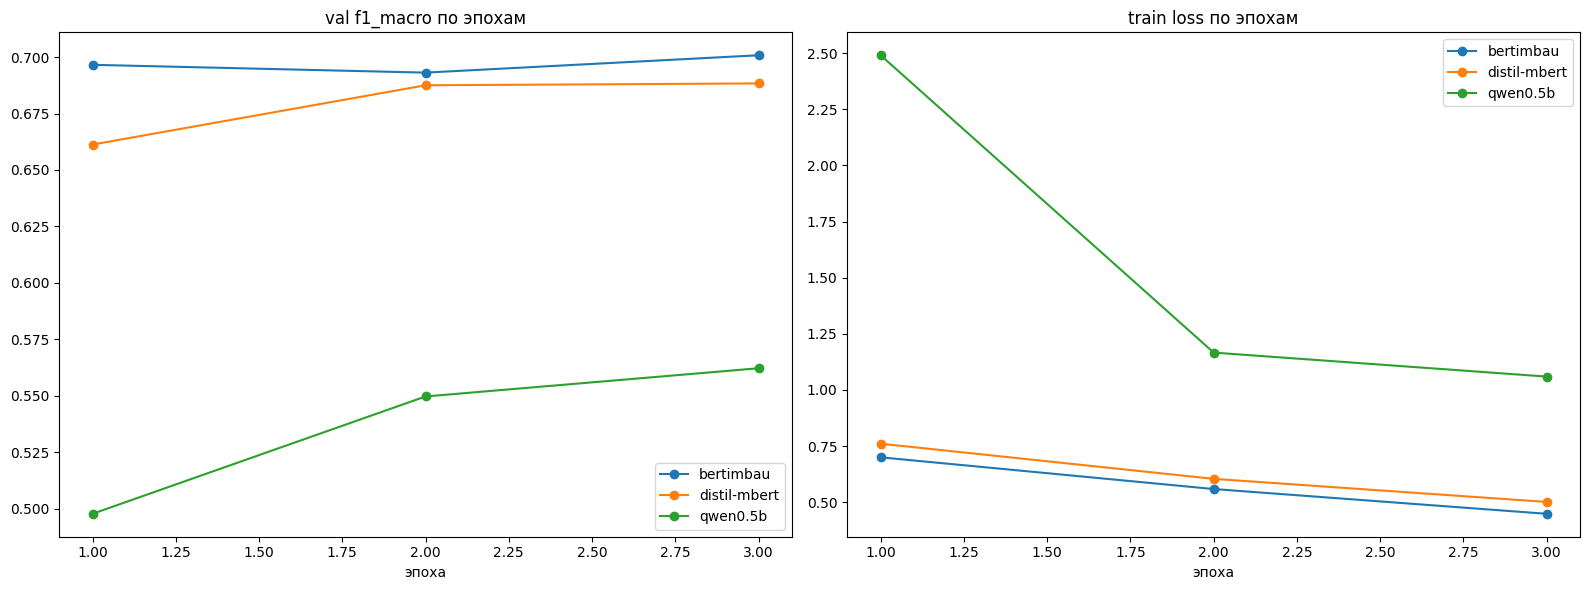

In [28]:
fig, ax = plt.subplots(1, 2, figsize = (16, 6))
for name, hist in [('bertimbau', hist_bert), ('distil-mbert', hist_distil), ('qwen0.5b', hist_qwen)]:
    ep = [h['epoch'] for h in hist]
    ax[0].plot(ep, [h['f1_macro'] for h in hist], marker = 'o', label = name)
    ax[1].plot(ep, [h['train_loss'] for h in hist], marker = 'o', label = name)
ax[0].set_title('val f1_macro по эпохам'); ax[0].set_xlabel('эпоха'); ax[0].legend()
ax[1].set_title('train loss по эпохам'); ax[1].set_xlabel('эпоха'); ax[1].legend()
plt.tight_layout()

confusion matrix для лучшей модели

              precision    recall  f1-score   support

    negative       0.85      0.80      0.82      2178
     neutral       0.27      0.54      0.36       711
    positive       0.96      0.86      0.91      5301

    accuracy                           0.82      8190
   macro avg       0.70      0.73      0.70      8190
weighted avg       0.87      0.82      0.84      8190



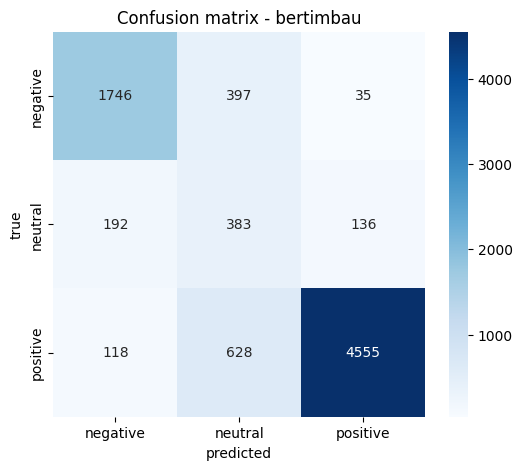

In [29]:
best = compare.index[0]
proba_map = {'bertimbau': (proba_bert, true_bert), 'distil-mbert': (proba_distil, true_distil), 'qwen0.5b': (proba_qwen, true_qwen)}
proba, true = proba_map[best]
pred = proba.argmax(1)

cm = confusion_matrix(true, pred)
plt.figure(figsize = (6, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = LABELS, yticklabels = LABELS)
plt.title('Confusion matrix - ' + best)
plt.xlabel('predicted'); plt.ylabel('true')

print(classification_report(true, pred, target_names = LABELS))

посмотрим на чём лучшая модель ошибается

In [30]:
err = test_df.copy()
err['pred'] = [id2label[p] for p in pred]
err = err[err['pred'] != err['sentiment']]
print('ошибок', len(err), 'из', len(test_df))
err[['review_comment_message', 'sentiment', 'pred']].head(10)

ошибок 1506 из 8190


,review_comment_message,sentiment,pred
7,"material muito fragil,achei que o produto era ...",negative,neutral
17,Estou esperando o meu produto ser enviado nova...,neutral,negative
18,Somente o toner amarelo chegou até o momento.,negative,neutral
27,Poderia ser excelente se o suporte não tivesse...,positive,neutral
29,Este é apenas uma parte do pedido.\r\nFalta en...,positive,neutral
35,Sempre comprei nas lannister nunca havia tido ...,neutral,negative
37,Devido outros quadros serem grandes preciso de...,positive,neutral
40,"Tudo certo com a loja, mas 1 mês esperando os ...",negative,neutral
42,bons produtos \r\nsao pequenos mas bons,positive,neutral
47,"O produto é muito bom, só veio com defeito de ...",negative,neutral


## Выводы по текстовой модели

Прогнал все модели, финальные метрики на тесте (8190 отзывов):

| модель | f1_macro | recall_neg | roc_auc | acc | параметров |
|---|---|---|---|---|---|
| BERTimbau | 0.70 | 0.80 | 0.91 | 0.82 | 109M |
| DistilBERT mult. | 0.67 | 0.79 | 0.89 | 0.80 | 135M |
| TF-IDF + LogReg | 0.65 | 0.79 | 0.87 | 0.79 | - |
| Qwen2.5-0.5B | 0.55 | 0.65 | 0.77 | 0.68 | 494M |

Что вижу по результатам:

- Лучшая - **BERTimbau**, как и ожидал. Он дообучен именно на португальском и выигрывает по всем метрикам (f1_macro 0.70, roc_auc 0.91). Это наша основная модель.
- **DistilBERT** идёт почти вровень (f1 0.67), но легче и учится примерно вдвое быстрее - если мало ресурсов или времени, можно брать его, теряем совсем немного качества.
- **TF-IDF бэйзлайн** оказался на удивление крепким: f1 0.65, а recall негатива (0.79) вообще на уровне трансформеров. То есть тяжёлые модели обгоняют, но не разгромно - на коротких отзывах tf-idf и так неплох.
- **Qwen неожиданно провалился** - f1 0.55, хуже даже бэйзлайна, хотя параметров в 4.5 раза больше и училась дольше всех (7.5 мин на эпоху). train_loss падал медленно, decoder-llm как классификатор за 3 эпохи просто не раскачалась. Вывод по проекту: для классификации текста энкодеры (bert) эффективнее декодеров, и больше параметров не значит лучше.

Какие ошибки чаще:

- тяжелее всего класс **neutral** (f1 всего 0.36, precision 0.27). Он малочисленный (8.7%) и размытый, по примерам ошибок видно что модель сваливает в neutral пограничные случаи - негатив с мягкой формулировкой и позитив с жалобой внутри (типа "продукт хороший, но пришёл с дефектом").
- зато **негатив ловим хорошо** (recall 0.80), а для удержания клиентов это и есть главная метрика - недовольного почти не пропускаем.

Как это идёт в offer engine:

- отдаю не argmax, а вероятности классов, в первую очередь P(negative) - roc_auc 0.91 говорит что она информативная.
- негатив -> извинение + более щедрый оффер, позитив -> лояльность и допродажа. neutral как отдельный триггер не использую, он ненадёжный - для офферов важнее разделение негатив / не негатив, и оно работает.
- основная модель BERTimbau, DistilBERT держим как лёгкую запасную (почти то же качество дешевле). Qwen для классификации не берём.